In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = pd.read_csv("marketing_campaign.csv", sep=";")

print("Dataset loaded successfully")

Dataset loaded successfully


In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
print("Total Missing Values:", df.isnull().sum().sum())

print("\nMissing Values by Column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Total Missing Values: 24

Missing Values by Column:
Income    24
dtype: int64


In [8]:
df["Income"] = df["Income"].fillna(df["Income"].median())

print("Missing Income values:", df["Income"].isnull().sum())

Missing Income values: 0


In [9]:
print("Total Missing Values After Cleaning:", df.isnull().sum().sum())

Total Missing Values After Cleaning: 0


In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [11]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (2240, 29)


In [13]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])

print("Date column converted successfully")
print(df["Dt_Customer"].head())

Date column converted successfully
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


In [14]:
print(df["Dt_Customer"].dtype)

datetime64[ns]


In [15]:
df["Age"] = 2026 - df["Year_Birth"]

df[["Year_Birth", "Age"]].head()

,Year_Birth,Age
0,1957,69
1,1954,72
2,1965,61
3,1984,42
4,1981,45


In [16]:
df["Age"].describe()

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

In [17]:
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

Minimum Age: 30
Maximum Age: 133


In [18]:
df[df["Age"] > 100][["ID", "Year_Birth", "Age"]]

,ID,Year_Birth,Age
192,7829,1900,126
239,11004,1893,133
339,1150,1899,127


In [19]:
df = df[df["Age"] <= 100].copy()

print("Age outliers removed successfully")
print("Dataset Shape:", df.shape)

Age outliers removed successfully
Dataset Shape: (2237, 30)


In [20]:
print("Minimum Age:", df["Age"].min())
print("Maximum Age:", df["Age"].max())

Minimum Age: 30
Maximum Age: 86


In [21]:
df["Total_Spending"] = (
    df["MntWines"]
    + df["MntFruits"]
    + df["MntMeatProducts"]
    + df["MntFishProducts"]
    + df["MntSweetProducts"]
    + df["MntGoldProds"]
)

print("Total Spending column created successfully")

Total Spending column created successfully


In [22]:
df[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
        "Total_Spending"
    ]
].head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


In [23]:
df["Total_Purchases"] = (
    df["NumWebPurchases"]
    + df["NumCatalogPurchases"]
    + df["NumStorePurchases"]
)

print("Total Purchases column created successfully")

Total Purchases column created successfully


In [24]:
df[
    [
        "Total_Spending",
        "Total_Purchases"
    ]
].head()

,Total_Spending,Total_Purchases
0,1617,22
1,27,4
2,776,20
3,53,6
4,422,14


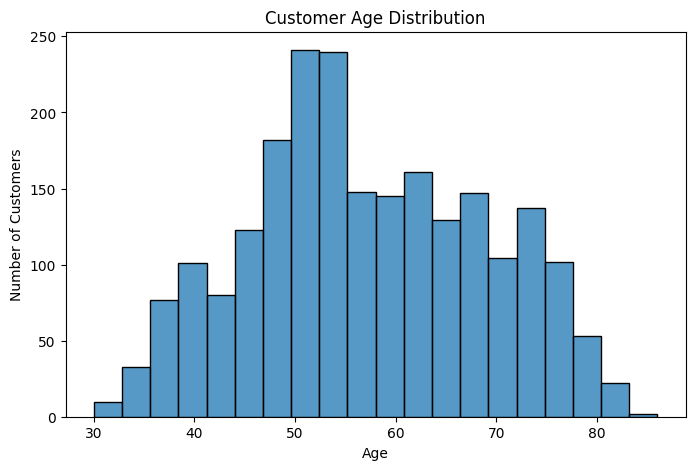

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=20
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [26]:
age_groups = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, 70, 100],
    labels=[
        "Below 30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "Above 70"
    ]
)

print(age_groups.value_counts().sort_index())

Age
Below 30      2
31-40       187
41-50       506
51-60       685
61-70       492
Above 70    365
Name: count, dtype: int64


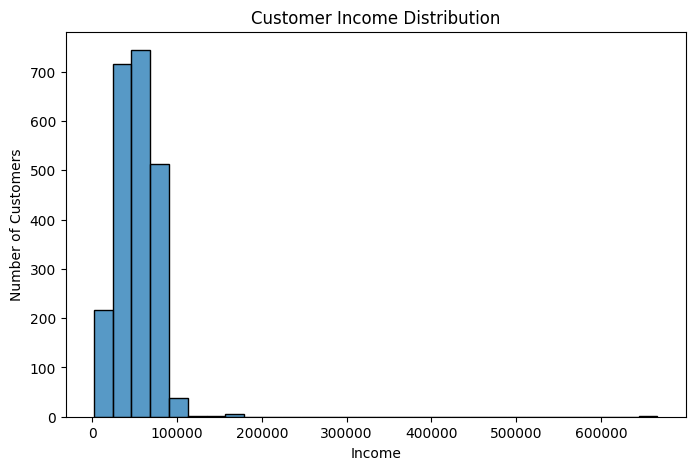

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Income",
    bins=30
)

plt.title("Customer Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
df["Income"].describe()

count      2237.000000
mean      52227.407689
std       25043.266830
min        1730.000000
25%       35523.000000
50%       51381.500000
75%       68281.000000
max      666666.000000
Name: Income, dtype: float64

In [29]:
print("Minimum Income:", df["Income"].min())
print("Maximum Income:", df["Income"].max())

df.nlargest(10, "Income")[["ID", "Income"]]

Minimum Income: 1730.0
Maximum Income: 666666.0


,ID,Income
2233,9432,666666.0
617,1503,162397.0
687,1501,160803.0
1300,5336,157733.0
164,8475,157243.0
1653,4931,157146.0
2132,11181,156924.0
655,5555,153924.0
1898,4619,113734.0
646,4611,105471.0


In [30]:
product_spending = df[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds"
    ]
].sum()

print(product_spending)

MntWines            680038
MntFruits            58767
MntMeatProducts     373393
MntFishProducts      83939
MntSweetProducts     60553
MntGoldProds         98358
dtype: int64


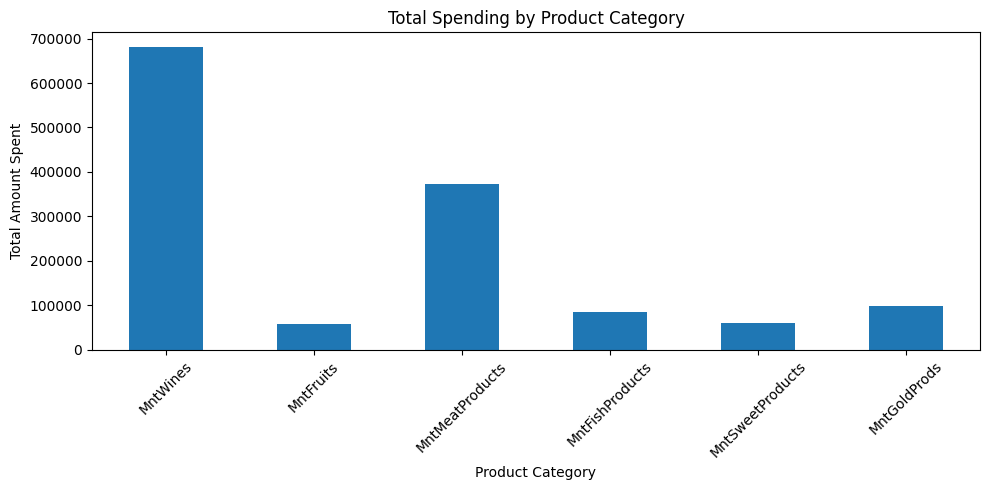

In [31]:
plt.figure(figsize=(10, 5))

product_spending.plot(kind="bar")

plt.title("Total Spending by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount Spent")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
highest_product = product_spending.idxmax()
highest_spending = product_spending.max()

print("Highest Spending Product:", highest_product)
print("Total Spending:", highest_spending)

Highest Spending Product: MntWines
Total Spending: 680038


In [33]:
channel_purchases = pd.Series({
    "Web": df["NumWebPurchases"].sum(),
    "Catalog": df["NumCatalogPurchases"].sum(),
    "Store": df["NumStorePurchases"].sum()
})

print(channel_purchases)

Web         9143
Catalog     5956
Store      12962
dtype: int64


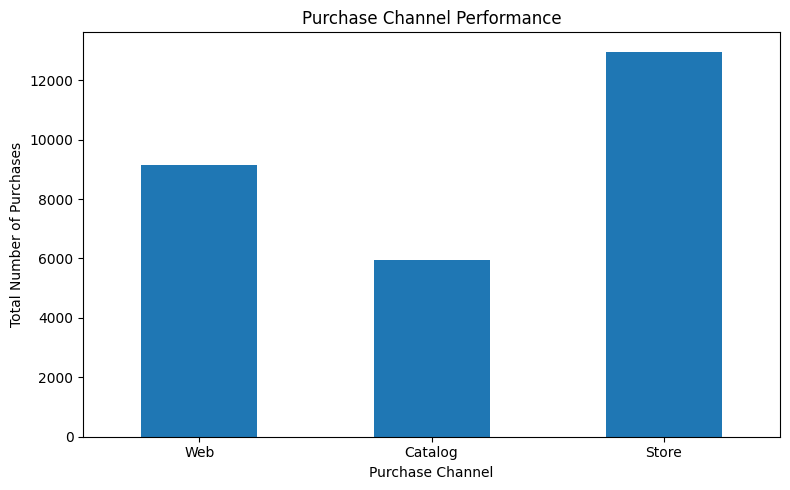

In [34]:
plt.figure(figsize=(8, 5))

channel_purchases.plot(kind="bar")

plt.title("Purchase Channel Performance")
plt.xlabel("Purchase Channel")
plt.ylabel("Total Number of Purchases")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [35]:
best_channel = channel_purchases.idxmax()
highest_purchases = channel_purchases.max()

print("Best Performing Channel:", best_channel)
print("Total Purchases:", highest_purchases)

Best Performing Channel: Store
Total Purchases: 12962


In [36]:
channel_percentage = (
    channel_purchases / channel_purchases.sum()
) * 100

print(channel_percentage.round(2))

Web        32.58
Catalog    21.23
Store      46.19
dtype: float64


In [37]:
funnel = pd.Series({
    "Total Customers": len(df),
    "Web Visitors": (df["NumWebVisitsMonth"] > 0).sum(),
    "Customers with Purchases": (df["Total_Purchases"] > 0).sum(),
    "Campaign Responders": df["Response"].sum()
})

print(funnel)

Total Customers             2237
Web Visitors                2226
Customers with Purchases    2231
Campaign Responders          334
dtype: int64


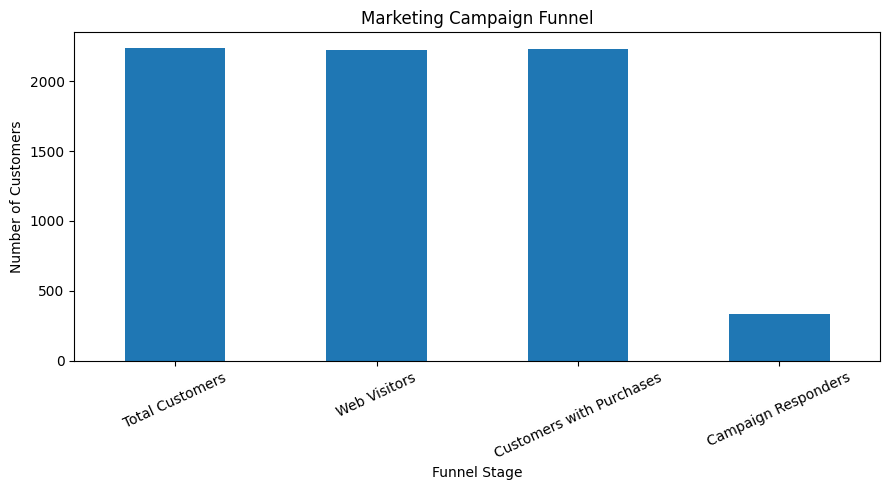

In [38]:
plt.figure(figsize=(9, 5))

funnel.plot(kind="bar")

plt.title("Marketing Campaign Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

In [39]:
response_rate = df["Response"].mean() * 100

print(f"Campaign Response Rate: {response_rate:.2f}%")

Campaign Response Rate: 14.93%


In [40]:
campaign_response = df["Response"].value_counts()

print("Campaign Response Count:")
print(campaign_response)

Campaign Response Count:
Response
0    1903
1     334
Name: count, dtype: int64


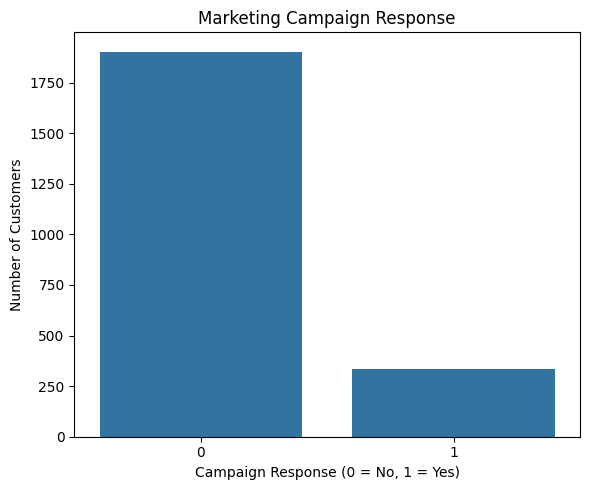

In [41]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Response"
)

plt.title("Marketing Campaign Response")
plt.xlabel("Campaign Response (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

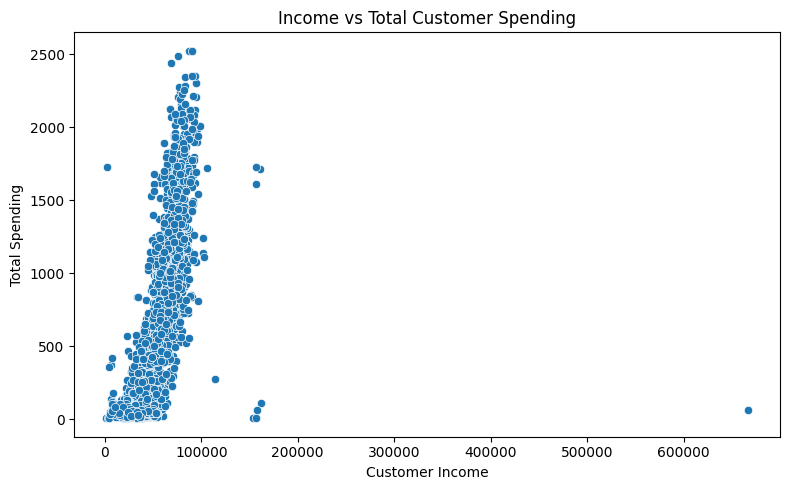

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending"
)

plt.title("Income vs Total Customer Spending")
plt.xlabel("Customer Income")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

In [43]:
income_spending_corr = df["Income"].corr(df["Total_Spending"])

print(
    f"Correlation between Income and Total Spending: "
    f"{income_spending_corr:.2f}"
)

Correlation between Income and Total Spending: 0.66


In [44]:
income_median = df["Income"].median()
spending_median = df["Total_Spending"].median()

def customer_segment(row):
    if (
        row["Income"] >= income_median
        and row["Total_Spending"] >= spending_median
    ):
        return "High Value"

    elif row["Total_Spending"] >= spending_median:
        return "High Spending"

    elif row["Income"] >= income_median:
        return "High Income"

    else:
        return "Standard"

df["Customer_Segment"] = df.apply(
    customer_segment,
    axis=1
)

print("Customer segments created successfully")

Customer segments created successfully


In [45]:
segment_counts = df["Customer_Segment"].value_counts()

print(segment_counts)

Customer_Segment
High Value       995
Standard         981
High Income      135
High Spending    126
Name: count, dtype: int64


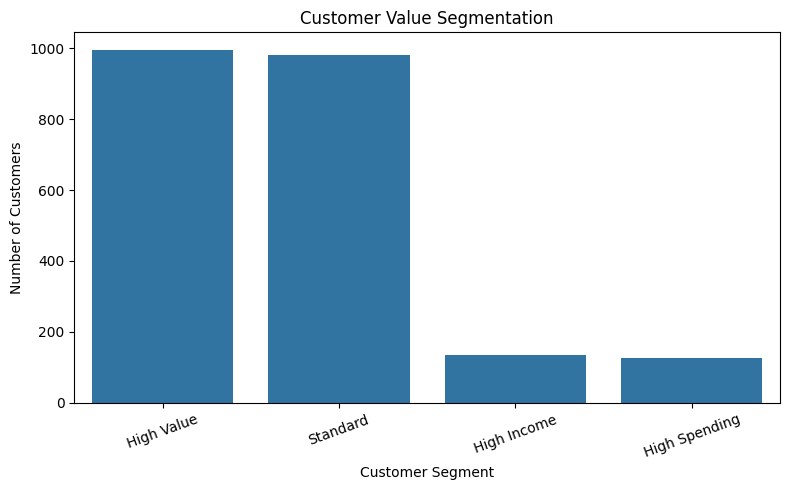

In [46]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Customer_Segment",
    order=df["Customer_Segment"].value_counts().index
)

plt.title("Customer Value Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [47]:
channel_summary = pd.DataFrame({
    "Channel": ["Web", "Catalog", "Store"],
    "Total_Purchases": [
        df["NumWebPurchases"].sum(),
        df["NumCatalogPurchases"].sum(),
        df["NumStorePurchases"].sum()
    ]
})

channel_summary["Purchase_Share_%"] = (
    channel_summary["Total_Purchases"]
    / channel_summary["Total_Purchases"].sum()
) * 100

channel_summary = channel_summary.sort_values(
    by="Total_Purchases",
    ascending=False
)

channel_summary

,Channel,Total_Purchases,Purchase_Share_%
2,Store,12962,46.192224
0,Web,9143,32.582588
1,Catalog,5956,21.225188


In [48]:
best_channel = channel_summary.iloc[0]["Channel"]
best_share = channel_summary.iloc[0]["Purchase_Share_%"]

print("Recommended High-Priority Channel:", best_channel)
print(f"Purchase Share: {best_share:.2f}%")

Recommended High-Priority Channel: Store
Purchase Share: 46.19%


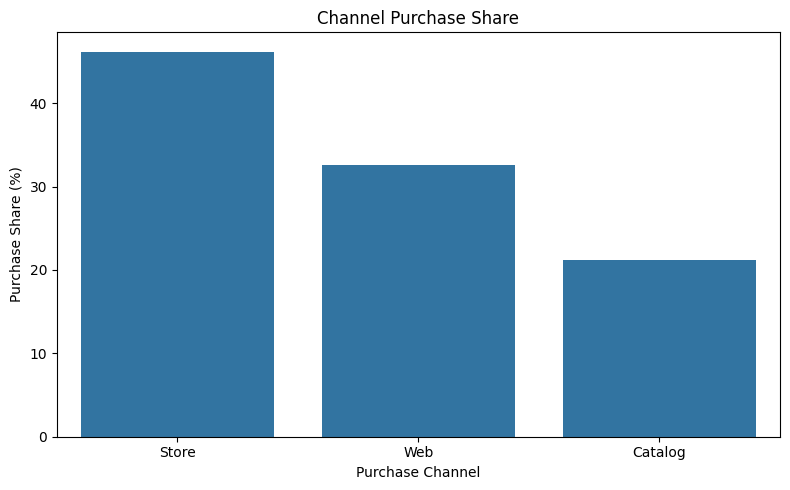

In [49]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=channel_summary,
    x="Channel",
    y="Purchase_Share_%"
)

plt.title("Channel Purchase Share")
plt.xlabel("Purchase Channel")
plt.ylabel("Purchase Share (%)")

plt.tight_layout()
plt.show()

# Final Business Insights

- Customer spending is concentrated in selected product categories, particularly wine and meat products.
- Customer income shows a positive relationship with total spending.
- High-value customers represent an important segment for personalized marketing campaigns.
- Purchase channel analysis shows differences in customer engagement across Store, Web, and Catalog channels.
- The marketing campaign response rate is relatively low compared with the overall customer base.
- The campaign funnel indicates a major conversion gap between customer activity and final campaign response.

# Marketing Budget Recommendation

Based on the exploratory data analysis, the highest-performing purchase channel should receive the largest share of the marketing budget because it generates the highest purchase volume.

The business should continue investing in the strongest channel while also increasing targeted digital campaigns for the Web channel to support future online growth.

High-value customers with higher income and spending should be prioritized through personalized offers, loyalty programs, and premium product promotions.

Wine and meat products should receive greater promotional focus because these categories contribute significantly to total customer spending.

The relatively low campaign response rate indicates that broad marketing campaigns may not be sufficiently effective. Customer segmentation and personalized campaigns should be used to improve conversion.

Since the dataset does not contain channel-level marketing cost, this recommendation is based on purchase performance rather than exact ROI.

In [50]:
df.to_csv(
    "cleaned_marketing_campaign.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [51]:
import os

print(
    "File exists:",
    os.path.exists("cleaned_marketing_campaign.csv")
)

File exists: True


In [52]:
print("Final Dataset Shape:", df.shape)
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

Final Dataset Shape: (2237, 33)
Total Rows: 2237
Total Columns: 33


In [53]:
print("New Analysis Columns:")

print(
    df[
        [
            "Age",
            "Total_Spending",
            "Total_Purchases",
            "Customer_Segment"
        ]
    ].head()
)

New Analysis Columns:
   Age  Total_Spending  Total_Purchases Customer_Segment
0   69            1617               22       High Value
1   72              27                4         Standard
2   61             776               20       High Value
3   42              53                6         Standard
4   45             422               14       High Value
